In [1]:
import numpy as np
import pandas as pd
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, BatchNormalization, Dropout
np.random.seed(42)

# Set paths and constants
data_dir = 'P:/Windows/Desktop/EC9580_COMPUTER_VISION/archive (4)'
train_path = f'{data_dir}/Train'
test_path = f'{data_dir}/Test'
IMG_HEIGHT, IMG_WIDTH, channels = 30, 30, 3

# Load and preprocess data
def load_data(data_dir, num_categories):
    image_data, image_labels = [], []
    for i in range(num_categories):
        path = os.path.join(data_dir, 'Train', str(i))
        images = os.listdir(path)
        for img in images:
            try:
                image = cv2.imread(os.path.join(path, img))
                image_fromarray = Image.fromarray(image, 'RGB')
                resized_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
                image_data.append(np.array(resized_image))
                image_labels.append(i)
            except Exception as e:
                print(f"Error in image {img}: {e}")
    image_data = np.array(image_data)
    image_labels = np.array(image_labels)
    return image_data, image_labels

# Build CNN model
def build_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
        MaxPool2D(pool_size=(2, 2)),
        BatchNormalization(axis=-1),
        Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
        MaxPool2D(pool_size=(2, 2)),
        BatchNormalization(axis=-1),
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(rate=0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Perform k-fold cross-validation
def k_fold_cross_validation(image_data, image_labels, num_classes, k=5, epochs=10, learning_rate=0.001):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    fold_accuracies = []
    for train_idx, val_idx in kf.split(image_data):
        X_train, X_val = image_data[train_idx], image_data[val_idx]
        y_train, y_val = image_labels[train_idx], image_labels[val_idx]

        X_train, X_val = X_train / 255.0, X_val / 255.0
        y_train = to_categorical(y_train, num_classes)
        y_val = to_categorical(y_val, num_classes)

        model = build_model((IMG_HEIGHT, IMG_WIDTH, channels), num_classes)
        model.compile(optimizer=Adam(learning_rate=learning_rate), 
                      loss='categorical_crossentropy', 
                      metrics=['accuracy'])

        aug = ImageDataGenerator(
            rotation_range=10,
            zoom_range=0.15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.15,
            horizontal_flip=False,
            fill_mode="nearest"
        )

        history = model.fit(aug.flow(X_train, y_train, batch_size=32),
                            epochs=epochs, 
                            validation_data=(X_val, y_val),
                            verbose=1)

        val_accuracy = history.history['val_accuracy'][-1]
        fold_accuracies.append(val_accuracy)

    print(f"Cross-validation accuracies: {fold_accuracies}")
    print(f"Mean accuracy: {np.mean(fold_accuracies)}")
    return model

# Final training and testing
def train_and_evaluate_final_model(model, train_data, train_labels, test_data, test_labels, num_classes, epochs=10):
    X_train, X_test = train_data / 255.0, test_data / 255.0
    y_train = to_categorical(train_labels, num_classes)

    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

    aug = ImageDataGenerator(
        rotation_range=10,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.15,
        horizontal_flip=False,
        fill_mode="nearest"
    )

    model.fit(aug.flow(X_train, y_train, batch_size=32), epochs=epochs)

    predictions = model.predict(X_test)
    predictions = np.argmax(predictions, axis=1)

    test_accuracy = accuracy_score(test_labels, predictions)
    print(f"Test data accuracy: {test_accuracy * 100:.2f}%")
    model.save("final_model.h5")

# Main execution
NUM_CATEGORIES = len(os.listdir(train_path))
image_data, image_labels = load_data(data_dir, NUM_CATEGORIES)

shuffle_idx = np.arange(image_data.shape[0])
np.random.shuffle(shuffle_idx)
image_data = image_data[shuffle_idx]
image_labels = image_labels[shuffle_idx]

model = k_fold_cross_validation(image_data, image_labels, NUM_CATEGORIES)

test_df = pd.read_csv(os.path.join(data_dir, 'Test.csv'))
imgs = test_df['Path'].values
test_labels = test_df['ClassId'].values

test_data = []
for img in imgs:
    try:
        image = cv2.imread(os.path.join(data_dir, img))
        image_fromarray = Image.fromarray(image, 'RGB')
        resized_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
        test_data.append(np.array(resized_image))
    except Exception as e:
        print(f"Error in image {img}: {e}")

test_data = np.array(test_data)
train_and_evaluate_final_model(model, image_data, image_labels, test_data, test_labels, NUM_CATEGORIES)


C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/10


C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step - accuracy: 0.4984 - loss: 2.0564 - val_accuracy: 0.9825 - val_loss: 0.0587
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9368 - loss: 0.2057 - val_accuracy: 0.9828 - val_loss: 0.0551
Epoch 3/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 44s 45ms/step - accuracy: 0.9642 - loss: 0.1168 - val_accuracy: 0.9857 - val_loss: 0.0458
Epoch 4/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.9707 - loss: 0.0974 - val_accuracy: 0.9958 - val_loss: 0.0162
Epoch 5/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.9778 - loss: 0.0722 - val_accuracy: 0.9926 - val_loss: 0.0237
Epoch 6/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.9788 - loss: 0.0688 - val_accuracy: 0.9940 - val_loss: 0.0192
Epoch 7/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - accuracy: 0.9798 - loss: 0.0650 - val_accuracy: 0.9943 - val_loss: 0.0194
Epoch 8/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - accuracy: 0.9804 - loss: 0.0557 - val_accurac

C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1226/1226 ━━━━━━━━━━━━━━━━━━━━ 52s 36ms/step - accuracy: 0.9852 - loss: 0.0500
Epoch 2/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.9871 - loss: 0.0424
Epoch 3/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9876 - loss: 0.0403
Epoch 4/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9886 - loss: 0.0363
Epoch 5/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.9888 - loss: 0.0358
Epoch 6/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 45s 37ms/step - accuracy: 0.9895 - loss: 0.0360
Epoch 7/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9916 - loss: 0.0263
Epoch 8/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9906 - loss: 0.0318
Epoch 9/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.9940 - loss: 0.0178
Epoch 10/10
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 39s 32ms/step - accuracy: 0.9909 - loss: 0.0315
395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step


Test data accuracy: 98.49%


In [8]:
from tensorflow.keras.models import load_model

classes = { 
    0:'Speed limit (20km/h)', 1:'Speed limit (30km/h)', 
    2:'Speed limit (50km/h)', 3:'Speed limit (60km/h)', 
    4:'Speed limit (70km/h)', 5:'Speed limit (80km/h)', 
    6:'End of speed limit (80km/h)', 7:'Speed limit (100km/h)', 
    8:'Speed limit (120km/h)', 9:'No passing', 
    10:'No passing veh over 3.5 tons', 
    11:'Right-of-way at intersection', 12:'Priority road', 
    13:'Yield', 14:'Stop', 15:'No vehicles', 
    16:'Veh > 3.5 tons prohibited', 17:'No entry', 
    18:'General caution', 19:'Dangerous curve left', 
    20:'Dangerous curve right', 21:'Double curve',  
    22:'Bumpy road', 23:'Slippery road', 
    24:'Road narrows on the right', 25:'Road work', 
    26:'Traffic signals', 27:'Pedestrians', 
    28:'Children crossing', 29:'Bicycles crossing', 
    30:'Beware of ice/snow', 31:'Wild animals crossing', 
    32:'End speed + passing limits', 33:'Turn right ahead', 
    34:'Turn left ahead', 35:'Ahead only', 
    36:'Go straight or right', 37:'Go straight or left', 
    38:'Keep right', 39:'Keep left', 
    40:'Roundabout mandatory', 41:'End of no passing', 
    42:'End no passing veh > 3.5 tons' 
}

def predict_traffic_sign(model_path, user_image):
    model = load_model(model_path)
    img = user_image.resize((IMG_HEIGHT, IMG_WIDTH))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)
    return classes[class_idx]


In [20]:
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps
import numpy as np
import cv2

def preprocess_image(user_image, img_height, img_width):
    img = np.array(user_image)
    if img.ndim == 2 or img.shape[-1] != 3:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    denoised_img = cv2.GaussianBlur(img, (5, 5), 0)
    resized_img = cv2.resize(denoised_img, (img_width, img_height))
    normalized_img = resized_img / 255.0
    input_img = np.expand_dims(normalized_img, axis=0)

    return input_img

def predict_traffic_sign(model_path, user_image, classes):
    model = load_model(model_path)
    preprocessed_img = preprocess_image(user_image, IMG_HEIGHT, IMG_WIDTH)
    predictions = model.predict(preprocessed_img)
    class_idx = np.argmax(predictions)

    return classes[class_idx]

user_image = Image.open("00034.png")
result = predict_traffic_sign("final_model.h5", user_image, classes)
print("Predicted traffic sign:", result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Predicted traffic sign: Speed limit (50km/h)


In [21]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

# Load the saved model
saved_model = load_model("final_model.h5")

# Preprocess test data
X_test = test_data / 255.0

# Predict using the saved model
saved_predictions = saved_model.predict(X_test)
saved_predictions = np.argmax(saved_predictions, axis=1)

# Calculate accuracy
re_test_accuracy = accuracy_score(test_labels, saved_predictions)
print(f"Re-Test Data Accuracy: {re_test_accuracy * 100:.2f}%")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(test_labels, saved_predictions))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(test_labels, saved_predictions))


395/395 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
Re-Test Data Accuracy: 98.49%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        60
           1       0.99      1.00      0.99       720
           2       1.00      0.99      0.99       750
           3       1.00      0.94      0.97       450
           4       1.00      1.00      1.00       660
           5       0.96      1.00      0.98       630
           6       1.00      0.99      0.99       150
           7       1.00      1.00      1.00       450
           8       1.00      1.00      1.00       450
           9       0.98      1.00      0.99       480
          10       1.00      0.98      0.99       660
          11       1.00      0.97      0.98       420
          12       1.00      0.99      0.99       690
          13       1.00      1.00      1.00       720
          14       1.00      1.00      1.00       270
          15       0.99      1.00      1

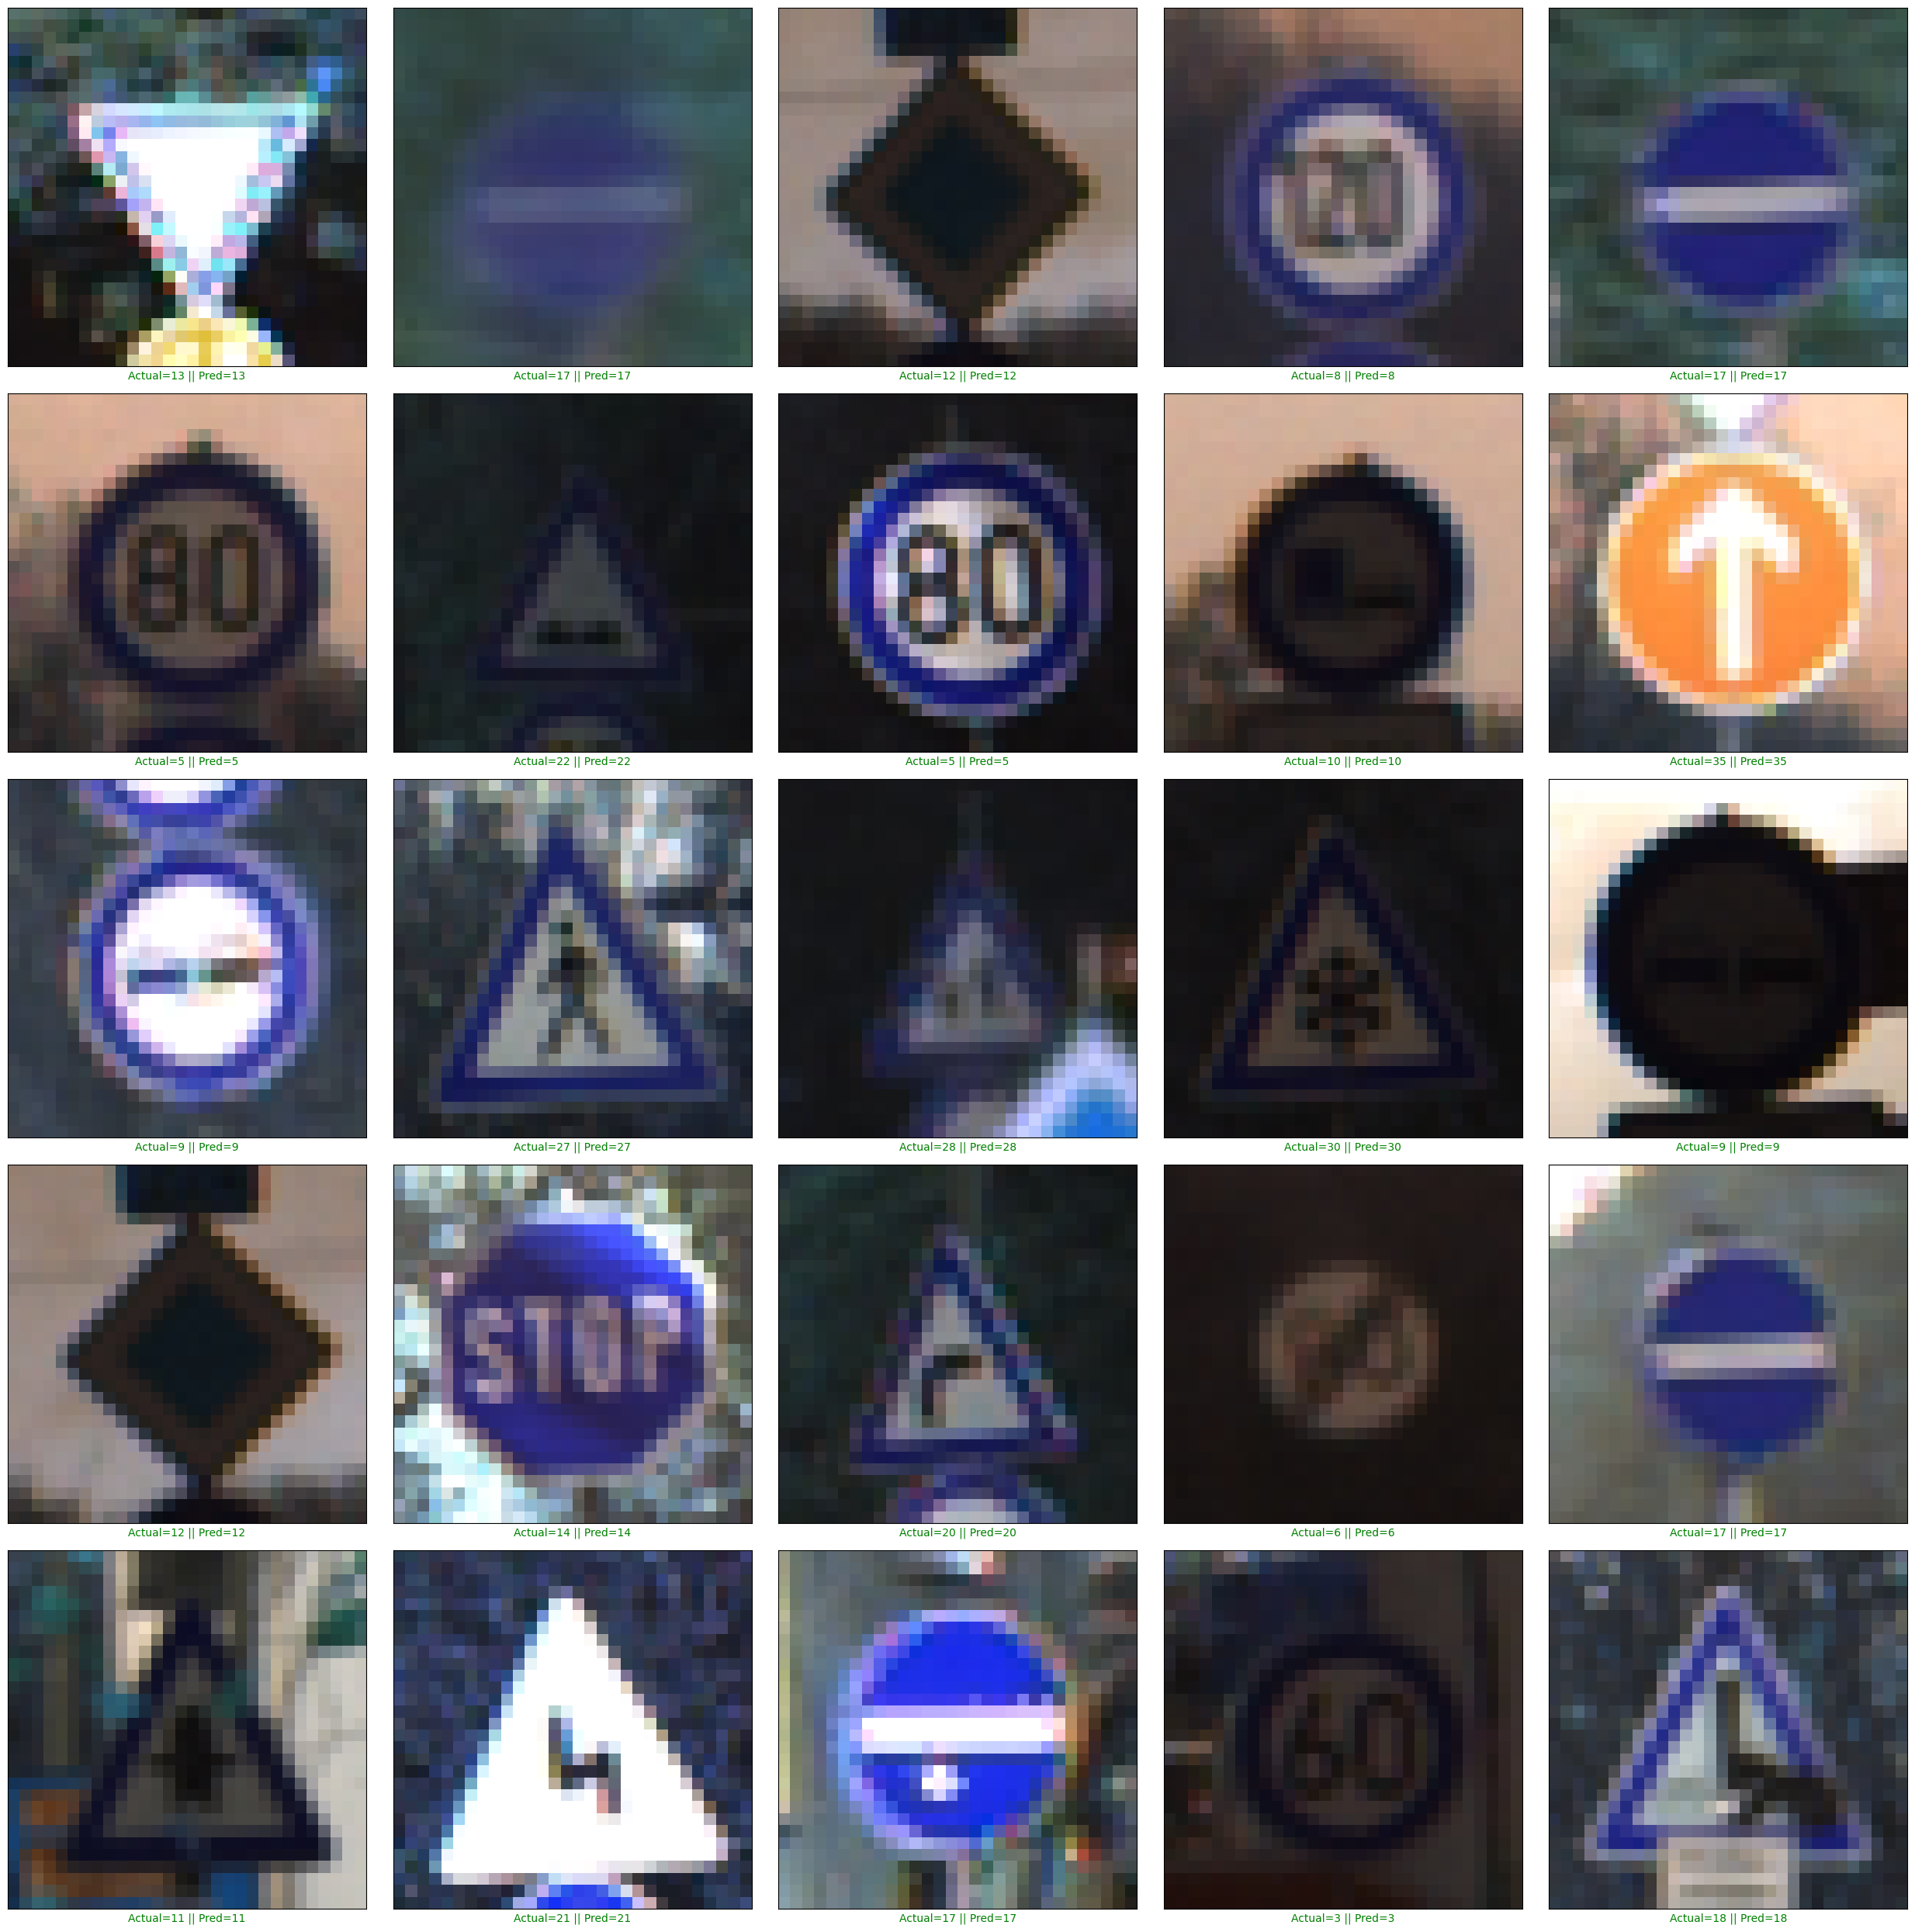

In [24]:
import random

# Randomly select 25 indices from the test data
random_indices = random.sample(range(len(X_test)), 25)

# Plot random 25 images with predictions and actual labels
plt.figure(figsize=(25, 25))
for i, idx in enumerate(random_indices):
    plt.subplot(5, 5, i + 1)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    # Get prediction and actual label
    prediction = saved_predictions[idx]
    actual = test_labels[idx]

    # Set color: green for correct, red for incorrect
    col = 'g' if prediction == actual else 'r'
    plt.xlabel(f'Actual={actual} || Pred={prediction}', color=col)

    # Show the image
    plt.imshow(X_test[idx])

plt.tight_layout()
plt.show()


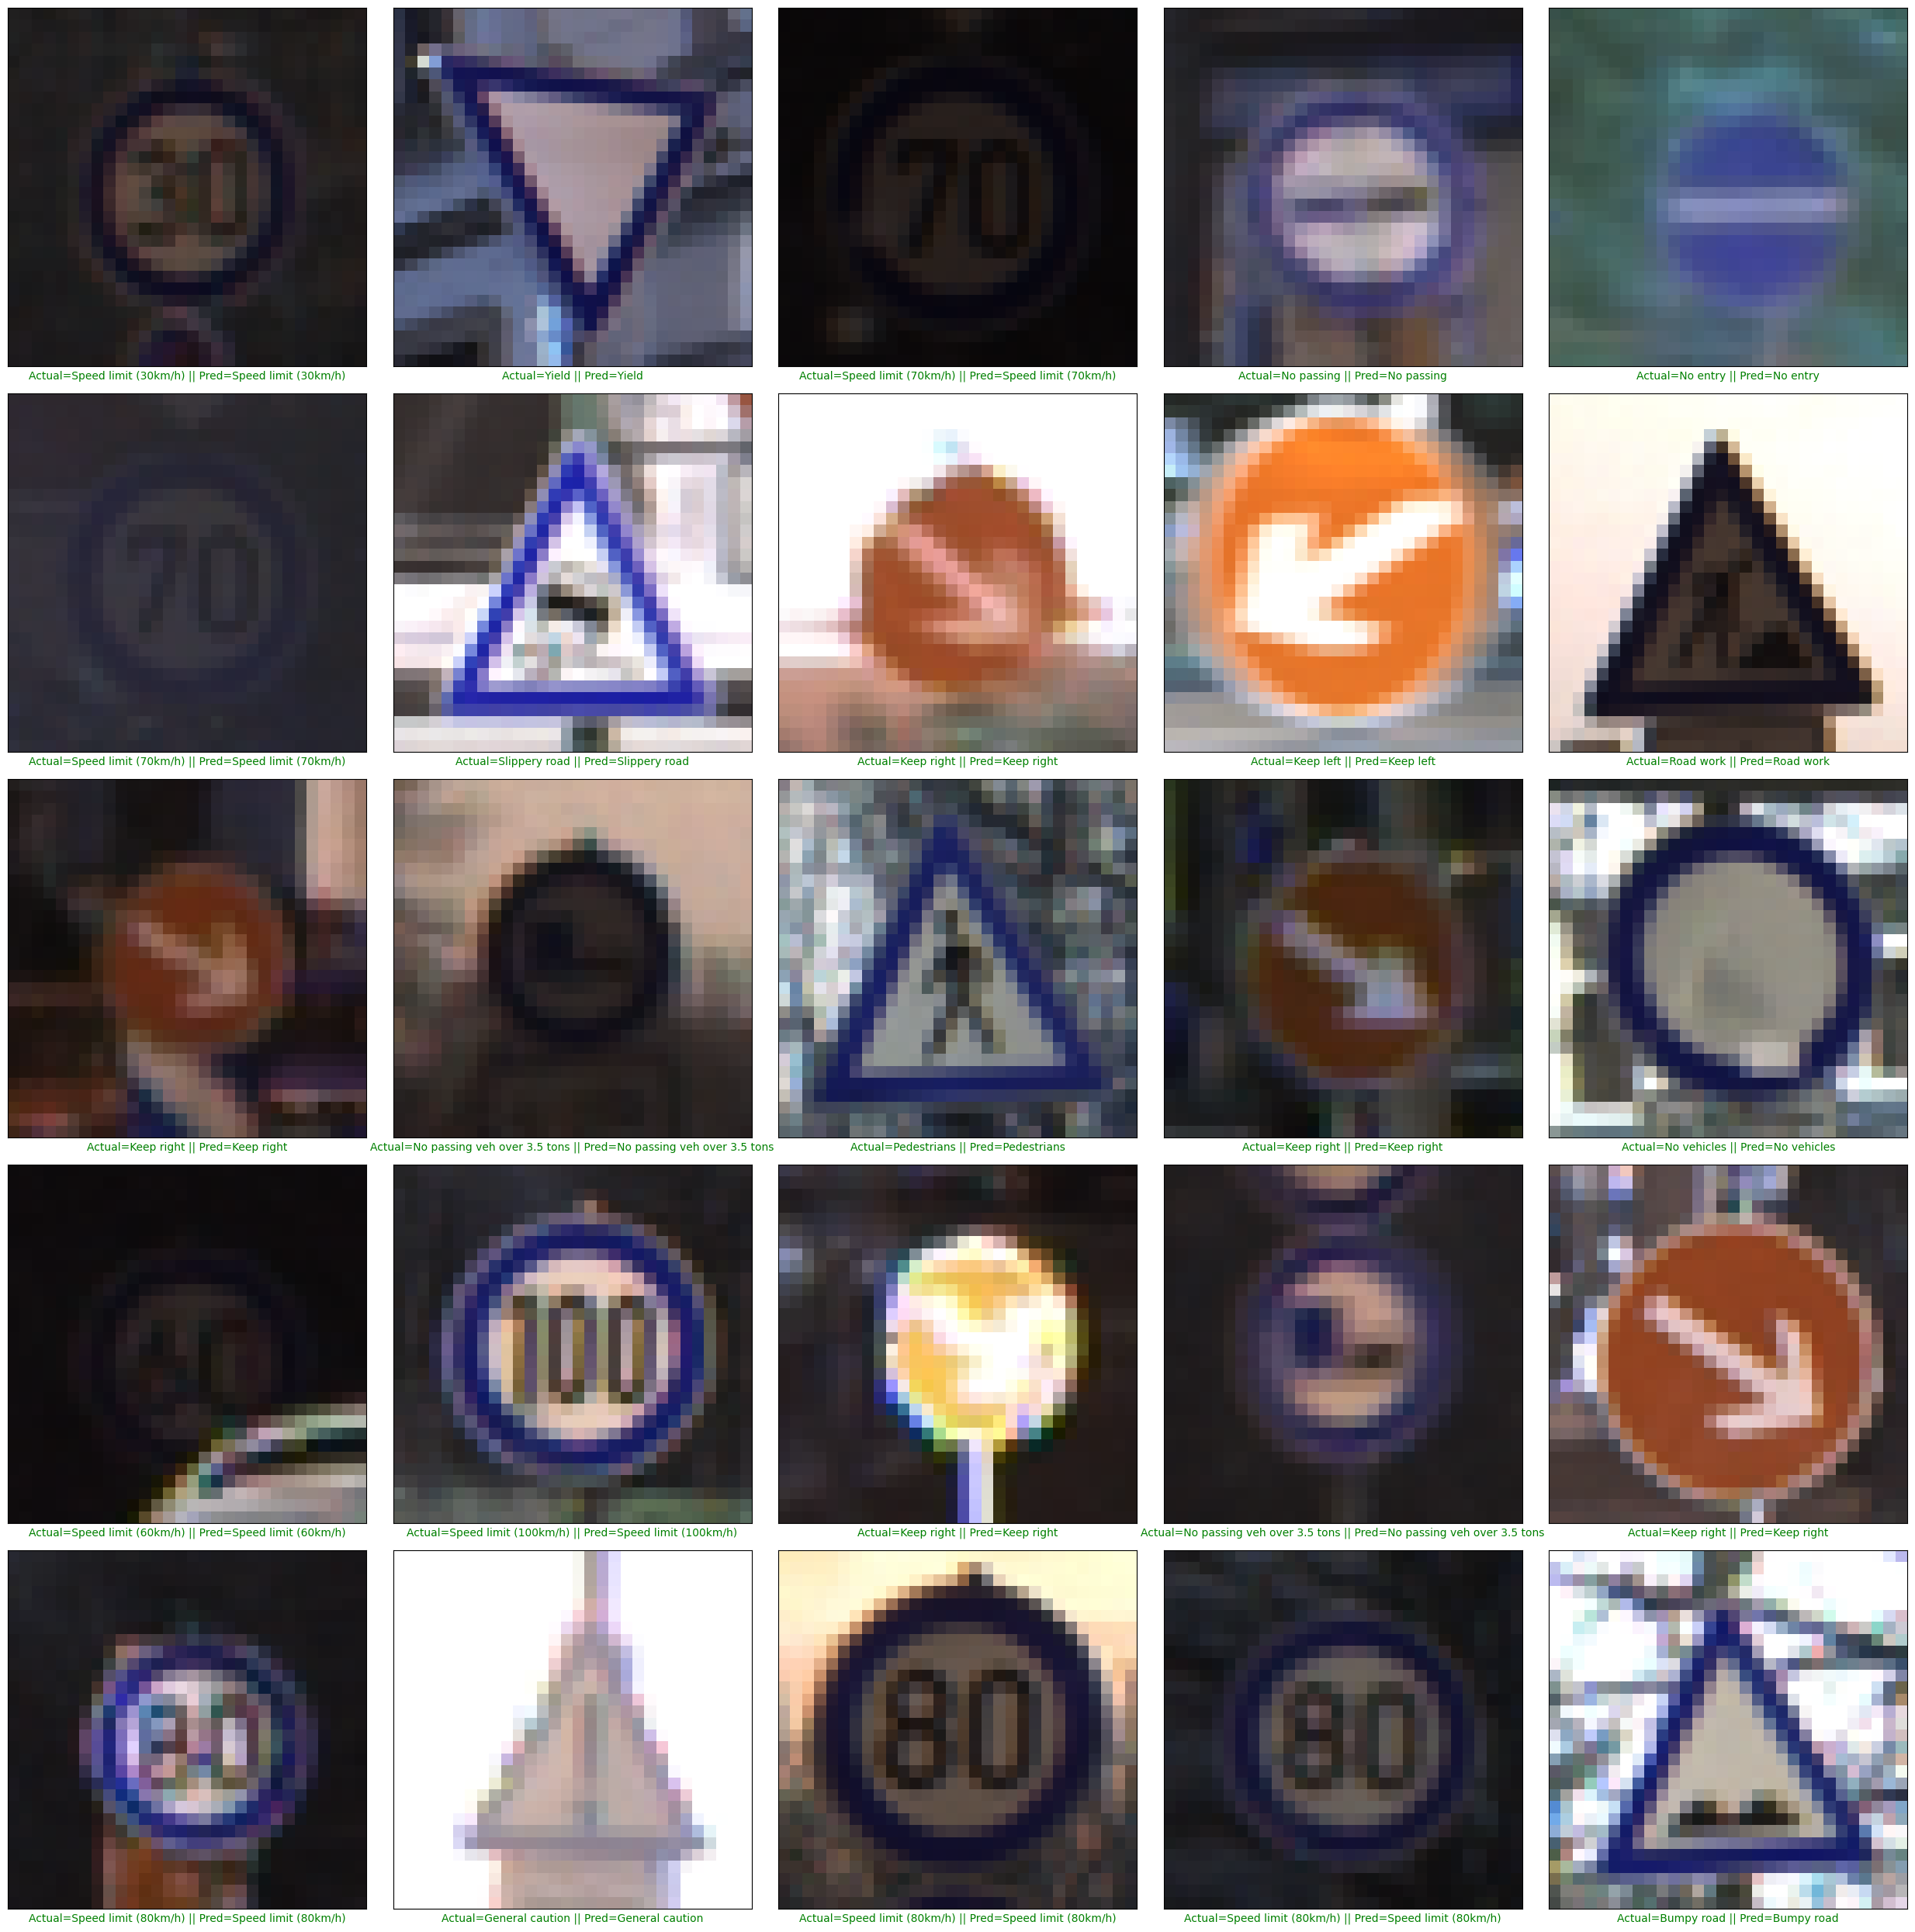

In [27]:
import random
import matplotlib.pyplot as plt

# Class labels dictionary
classes = { 
    0:'Speed limit (20km/h)', 1:'Speed limit (30km/h)', 
    2:'Speed limit (50km/h)', 3:'Speed limit (60km/h)', 
    4:'Speed limit (70km/h)', 5:'Speed limit (80km/h)', 
    6:'End of speed limit (80km/h)', 7:'Speed limit (100km/h)', 
    8:'Speed limit (120km/h)', 9:'No passing', 
    10:'No passing veh over 3.5 tons', 
    11:'Right-of-way at intersection', 12:'Priority road', 
    13:'Yield', 14:'Stop', 15:'No vehicles', 
    16:'Veh > 3.5 tons prohibited', 17:'No entry', 
    18:'General caution', 19:'Dangerous curve left', 
    20:'Dangerous curve right', 21:'Double curve',  
    22:'Bumpy road', 23:'Slippery road', 
    24:'Road narrows on the right', 25:'Road work', 
    26:'Traffic signals', 27:'Pedestrians', 
    28:'Children crossing', 29:'Bicycles crossing', 
    30:'Beware of ice/snow', 31:'Wild animals crossing', 
    32:'End speed + passing limits', 33:'Turn right ahead', 
    34:'Turn left ahead', 35:'Ahead only', 
    36:'Go straight or right', 37:'Go straight or left', 
    38:'Keep right', 39:'Keep left', 
    40:'Roundabout mandatory', 41:'End of no passing', 
    42:'End no passing veh > 3.5 tons' 
}

# Randomly select 25 indices from the test data
random_indices = random.sample(range(len(X_test)), 25)

# Plot random 25 images with predictions and actual labels
plt.figure(figsize=(25, 25))
for i, idx in enumerate(random_indices):
    plt.subplot(5, 5, i + 1)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    # Get prediction and actual label
    prediction = saved_predictions[idx]
    actual = test_labels[idx]

    # Map the numerical prediction and actual to class names
    predicted_class = classes[prediction]
    actual_class = classes[actual]

    # Set color: green for correct, red for incorrect
    col = 'g' if prediction == actual else 'r'
    plt.xlabel(f'Actual={actual_class} || Pred={predicted_class}', color=col)

    # Show the image
    plt.imshow(X_test[idx])

# Adjust layout to make space for class names
plt.tight_layout()
